In [1]:
import numpy as np
import matplotlib.pyplot as plt
# plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
#import seaborn as sns
import pandas as pd
import os
import cooler
import cooltools
import scipy

import cooltools.lib.plotting
from matplotlib.colors import LogNorm

In [2]:
## Analysis of 2024 MRC5 DpnII data

DIR='/home/srirvs/data_from_asp2a/rep_hic_analysis/analyses/analyses_2024-05-12/hic_and_mcool_files_Correct_Strategy/dups_MAPQ_30'

clr_rephic_hu3 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2024-02-and-04-Rep-HiC-HU-MRC5-WT-merged-rerun.merged_sort.MAPQ.30.10k.cool')

clr_rephic_nt3 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2024-02-and-04-Rep-HiC-UT-MRC5-WT-merged-rerun.merged_sort.MAPQ.30.10k.cool')

clr_rephic_hu_g9a3 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2024-02-and-04-Rep-HiC-HU-MRC5-G9ai-merged.merged_sort.MAPQ.30.10k.cool')

clr_rephic_nt_g9a3 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2024-02-and-04-Rep-HiC-UT-MRC5-G9ai-merged.merged_sort.MAPQ.30.10k.cool')

clr_hic_hu3 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2024-02-16-HiC-HU-MRC5-WT.merged_sort.MAPQ.30.10k.cool')

clr_hic_nt3 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2024-02-16-HiC-NT-MRC5-WT.merged_sort.MAPQ.30.10k.cool')

clr_hic_hu_g9a3 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2025-11-12-HiC-HU-MRC5-G9ai.merged_sort.MAPQ.30.10k.cool')

clr_hic_nt_g9a3 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2025-11-12-HiC-UT-MRC5-G9ai.merged_sort.MAPQ.30.10k.cool')

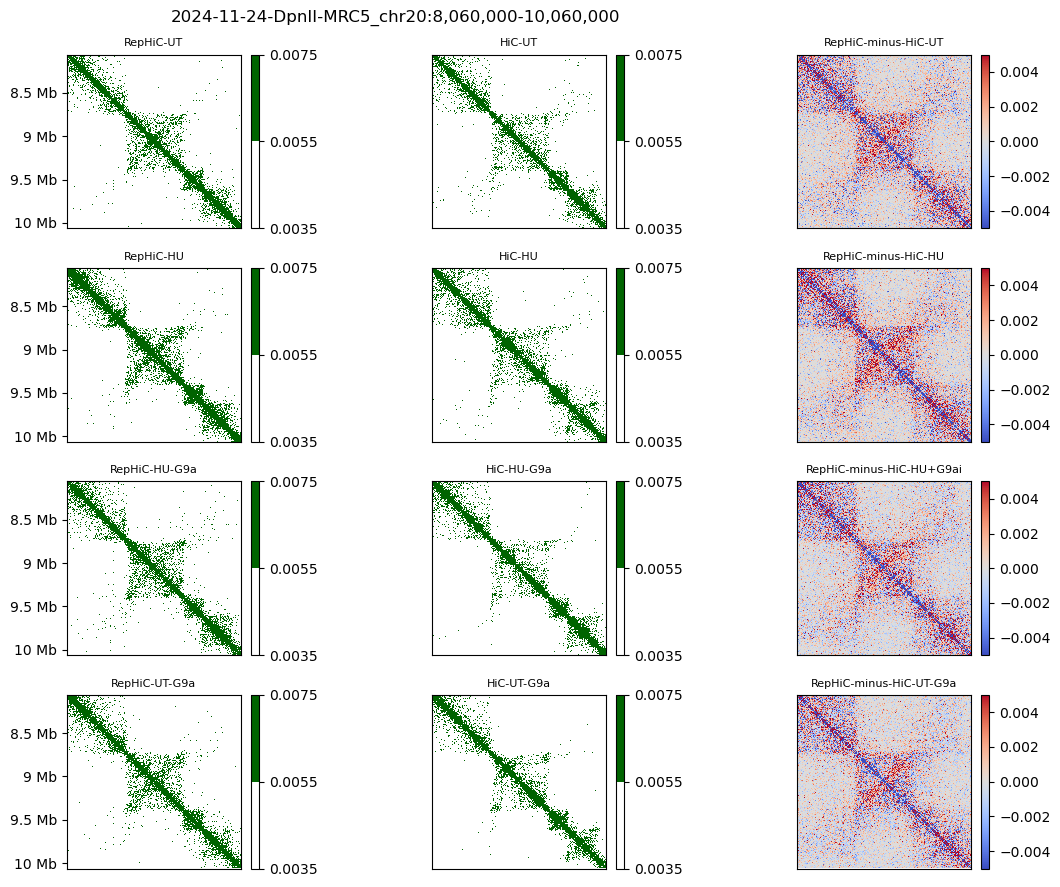

In [5]:
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap

# chrom_number = "chr8"
# mid = 137170000
# left_anchor_mid = 127975000
# right_anchor_mid = 128325000

chrom_number = "chr20"
mid = 9060000
# left_anchor_mid = 8800000
# right_anchor_mid = 9320000

# chrom_number = "chr1"
# mid = 70350000
# left_anchor_mid = 18140000
# right_anchor_mid = 18660000
               
# chrom_number = "chr11"
# mid = 106410000
# left_anchor_mid = 81350000
# right_anchor_mid = 81730000


start = mid-1000000
end = mid+1000000
region = (chrom_number, start, end)

# left_start = left_anchor_mid-250000
# left_end = left_anchor_mid+250000

# right_start = right_anchor_mid-250000
# right_end = right_anchor_mid+250000

# row_locus = (chrom_number, left_start,  left_end)
# column_locus = (chrom_number, right_start,  right_end)

left_start = mid-500000
left_end = mid+500000

right_start = mid-500000
right_end = mid+500000

row_locus = (chrom_number, left_start,  left_end)
column_locus = (chrom_number, right_start,  right_end)

# # Define custom colormap (white to red)
# colors = ['white', 'red']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # norm = LogNorm(vmin=0.001*6,vmax=0.001*7)

vmin=-0.005
vmax=0.005

rephic_ut_2 = clr_rephic_nt3
hic_ut_2 = clr_hic_nt3

rephic_hu_2 = clr_rephic_hu3
hic_hu_2 = clr_hic_hu3

rephic_hu_mut_2 = clr_rephic_hu_g9a3
hic_hu_mut_2 = clr_hic_hu_g9a3

rephic_ut_mut_2 = clr_rephic_nt_g9a3
hic_ut_mut_2 = clr_hic_nt_g9a3 

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')

f, axs = plt.subplots(ncols=3, nrows=4,
    figsize=(9, 9))

plt.subplots_adjust(bottom=0.1, top=0.5, hspace=0.5, wspace=0.5)

# Define custom colormap (white to red)
colors = ['white', 'darkgreen']
custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# Define breakpoints for color transitions
breakpoints = [0.0035, 0.0055, 0.0075]  # Values at which colors change
norm = BoundaryNorm(breakpoints, custom_cmap.N)

# vmin=-0.0035
# vmax=0.0035

def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

ax = axs[0,0]
# Define breakpoints for color transitions

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # Define breakpoints for color transitions
# breakpoints = [0.003, 0.005, 0.007]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(
    (rephic_ut_2.matrix(balance=True).fetch(region)[:]),
    norm = norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('RepHiC-UT', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# cbar.remove()
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
format_ticks(ax)

ax = axs[0,1]

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # Define breakpoints for color transitions
# breakpoints = [0.003, 0.005, 0.007]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(
    (hic_ut_2.matrix(balance=True).fetch(region)[:]),
    norm = norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('HiC-UT', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)

ax = axs[0,2]

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # Define breakpoints for color transitions
# breakpoints = [-0.005, 0.003, 0.005]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(
   (rephic_ut_2.matrix(balance=True).fetch(region)[:]-hic_ut_2.matrix(balance=True).fetch(region)[:]),
    # vmin=0.002,vmax=vmax,
    vmin=vmin,vmax=vmax,
    cmap='coolwarm', extent=(start, end, end, start)
);
ax.set_title('RepHiC-minus-HiC-UT', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)
######################################################################################
######################################################################################
ax = axs[1,0]

# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # Define breakpoints for color transitions
# breakpoints = [0.003, 0.005, 0.007]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(    
    (rephic_hu_2.matrix(balance=True).fetch(region)[:]),
    norm = norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('RepHiC-HU', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# cbar.remove()
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
format_ticks(ax)

ax = axs[1,1]

# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # Define breakpoints for color transitions
# breakpoints = [0.003, 0.005, 0.007]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(
    (hic_hu_2.matrix(balance=True).fetch(region)[:]),
    norm = norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('HiC-HU', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)

ax = axs[1,2]

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # Define breakpoints for color transitions
# breakpoints = [-0.005, 0.003, 0.005]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(
    (rephic_hu_2.matrix(balance=True).fetch(region)[:]-hic_hu_2.matrix(balance=True).fetch(region)[:]),
    vmin=vmin,vmax=vmax,
    cmap='coolwarm', extent=(start, end, end, start)
);
ax.set_title('RepHiC-minus-HiC-HU', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)
######################################################################################
######################################################################################
ax = axs[2,0]

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# Define breakpoints for color transitions
# breakpoints = [0.003, 0.0055, 0.007]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(    
    (rephic_hu_mut_2.matrix(balance=True).fetch(region)[:]),
    norm=norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('RepHiC-HU-G9a', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# cbar.remove()
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
format_ticks(ax)

# axs[2,1].axis("off")
ax = axs[2,1]
im = ax.matshow(
    (hic_hu_mut_2.matrix(balance=True).fetch(region)[:]),
    norm=norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('HiC-HU-G9a', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# # ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# # format_ticks(ax)

ax = axs[2,2]
# row_locus = "chr1:18005000-18415000"  # Genomic region for the row
# column_locus = "chr1:18225000-18635000 "  # Genomic region for the column
# clr.matrix(balance=True).fetch(locus1, locus2)

# norm = LogNorm(vmin=-0.001*6,vmax=0.001*6)

im = ax.matshow(
    rephic_hu_mut_2.matrix(balance=True).fetch(region)[:]-hic_hu_mut_2.matrix(balance=True).fetch(region)[:],
    vmin=vmin,vmax=vmax,
    cmap='coolwarm', extent= (start, end, end, start)
);
ax.set_title('RepHiC-minus-HiC-HU+G9ai', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)
######################################################################################
######################################################################################
ax = axs[3,0]

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# Define breakpoints for color transitions
# breakpoints = [0.003, 0.0055, 0.007]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(    
    (rephic_ut_mut_2.matrix(balance=True).fetch(region)[:]),
    norm=norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('RepHiC-UT-G9a', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# cbar.remove()
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
format_ticks(ax)

# axs[2,1].axis("off")
ax = axs[3,1]
im = ax.matshow(
    (hic_ut_mut_2.matrix(balance=True).fetch(region)[:]),
    norm=norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('HiC-UT-G9a', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)

ax = axs[3,2]
# row_locus = "chr1:18005000-18415000"  # Genomic region for the row
# column_locus = "chr1:18225000-18635000 "  # Genomic region for the column
# clr.matrix(balance=True).fetch(locus1, locus2)

# norm = LogNorm(vmin=-0.001*6,vmax=0.001*6)

im = ax.matshow(
    rephic_ut_mut_2.matrix(balance=True).fetch(region)[:]-hic_ut_mut_2.matrix(balance=True).fetch(region)[:],
    vmin=vmin,vmax=vmax,
    cmap='coolwarm', extent= (start, end, end, start)
);
ax.set_title('RepHiC-minus-HiC-UT-G9a', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)
######################################################################################################
######################################################################################################
f.suptitle(f"2024-11-24-DpnII-MRC5_{chrom_number}:{start:,}-{end:,}", fontsize=12)
f.tight_layout(rect=[0, 0, 1.3, 1])

# plt.savefig('/home/srirvs/data_from_asp2a/revision_files/rev2/rev2_pt5/'+"2024-02-and-04-Rep-HiC-HU-and-UT.10k-and-25k.combined.aggregate.Fountains-with-G9a.for.Kaustav.pdf",\
#             bbox_inches='tight', dpi=800, format = 'pdf')

plt.savefig('/home/srirvs/data_from_asp2a/revision_files/rev1/rev1_pt7_apa_single_and_aggregate_fountains/'+\
            f'2024-11-24-DpnII-MRC5_Rep2_{chrom_number}:{start:,}-{end:,}.v2.svg',\
            bbox_inches='tight', dpi=800, format = 'svg')

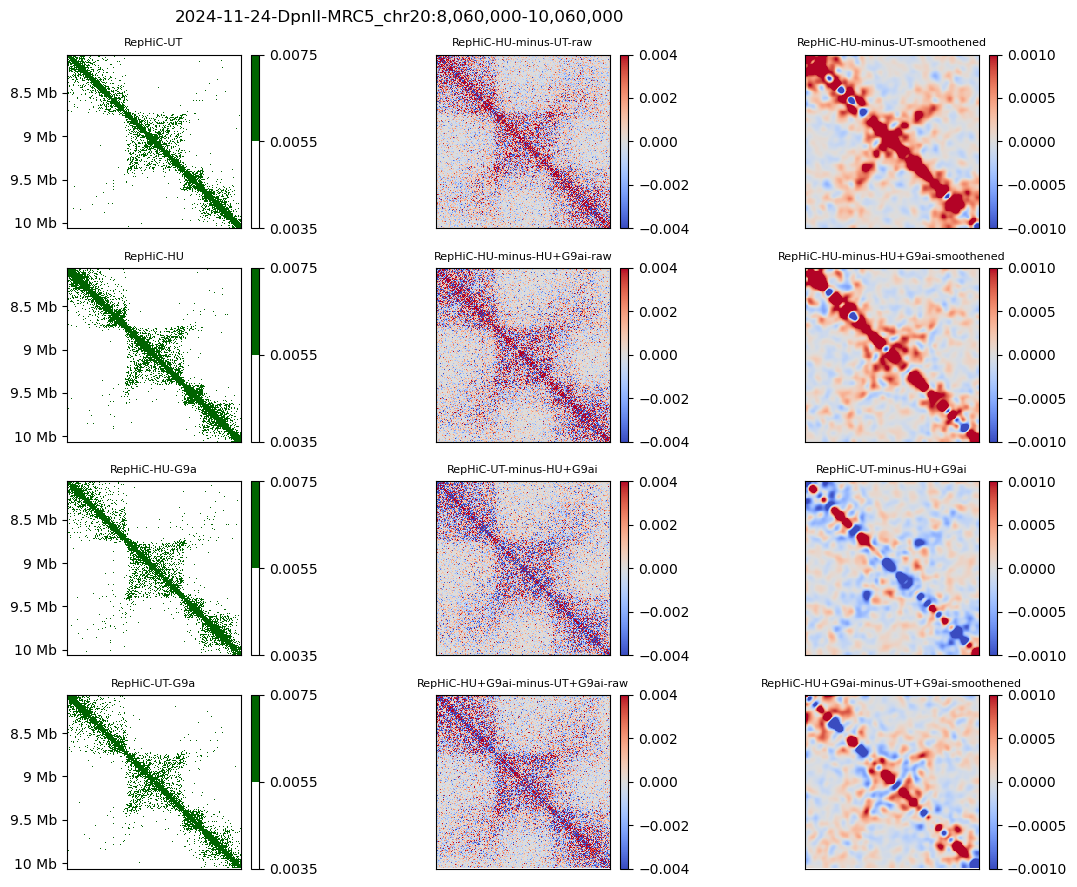

In [6]:
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap

# chrom_number = "chr8"
# mid = 128150000
# left_anchor_mid = 127975000
# right_anchor_mid = 128325000

# chrom_number = "chr1"
# mid = 70350000
# left_anchor_mid = 18140000
# right_anchor_mid = 18660000
               
# chrom_number = "chr11"
# mid = 106410000
# left_anchor_mid = 81350000
# right_anchor_mid = 81730000

# chrom_number = "chr20"
# mid = 9060000
# left_anchor_mid = 8800000
# right_anchor_mid = 9320000

# start = mid-1000000
# end = mid+1000000
# region = (chrom_number, start, end)

# left_start = left_anchor_mid-250000
# left_end = left_anchor_mid+250000

# right_start = right_anchor_mid-250000
# right_end = right_anchor_mid+250000

# row_locus = (chrom_number, left_start,  left_end)
# column_locus = (chrom_number, right_start,  right_end)

# left_start = mid-500000
# left_end = mid+500000

# right_start = mid-500000
# right_end = mid+500000

# row_locus = (chrom_number, left_start,  left_end)
# column_locus = (chrom_number, right_start,  right_end)

# # Define custom colormap (white to red)
# colors = ['white', 'red']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # norm = LogNorm(vmin=0.001*6,vmax=0.001*7)

vmin=-0.001
vmax=0.001

vmin_raw=-0.004
vmax_raw=0.004

# rephic_ut_2 = clr_rephic_nt3
# hic_ut_2 = clr_hic_nt3

# rephic_hu_2 = clr_rephic_hu3
# hic_hu_2 = clr_hic_hu3

# rephic_hu_mut_2 = clr_rephic_hu_g9a3
# hic_hu_mut_2 = clr_hic_hu_g9a3

# rephic_ut_mut_2 = clr_rephic_nt_g9a3
# hic_ut_mut_2 = clr_hic_nt_g9a3 

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')

f, axs = plt.subplots(ncols=3, nrows=4,
    figsize=(9, 9))

plt.subplots_adjust(bottom=0.1, top=0.5, hspace=0.5, wspace=0.5)

# Define custom colormap (white to red)
colors = ['white', 'darkgreen']
custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# Define breakpoints for color transitions
breakpoints = [0.0035, 0.0055, 0.0075]  # Values at which colors change
norm = BoundaryNorm(breakpoints, custom_cmap.N)



def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

ax = axs[0,0]
# Define breakpoints for color transitions

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # Define breakpoints for color transitions
# breakpoints = [0.003, 0.005, 0.007]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(
    (rephic_ut_2.matrix(balance=True).fetch(region)[:]),
    norm = norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('RepHiC-UT', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# cbar.remove()
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
format_ticks(ax)

ax = axs[0,1]

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # Define breakpoints for color transitions
# breakpoints = [-0.005, 0.003, 0.005]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(
   (rephic_hu_2.matrix(balance=True).fetch(region)[:]-rephic_ut_2.matrix(balance=True).fetch(region)[:]),
    # vmin=0.002,vmax=vmax,
    vmin=vmin_raw,vmax=vmax_raw,
    cmap='coolwarm', extent=(start, end, end, start)
);

ax.set_title('RepHiC-HU-minus-UT-raw', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)

ax = axs[0,2]

im = ax.matshow(
    scipy.ndimage.gaussian_filter(rephic_hu_2.matrix(balance=True).fetch(region)[:]-rephic_ut_2.matrix(balance=True).fetch(region)[:], sigma=3),
    vmin=vmin,vmax=vmax,
    cmap='coolwarm', extent= (start, end, end, start)
);

ax.set_title('RepHiC-HU-minus-UT-smoothened', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)
######################################################################################
######################################################################################
ax = axs[1,0]

# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # Define breakpoints for color transitions
# breakpoints = [0.003, 0.005, 0.007]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(    
    (rephic_hu_2.matrix(balance=True).fetch(region)[:]),
    norm = norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('RepHiC-HU', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# cbar.remove()
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
format_ticks(ax)

ax = axs[1,1]

im = ax.matshow(
    (rephic_hu_2.matrix(balance=True).fetch(region)[:]-rephic_hu_mut_2.matrix(balance=True).fetch(region)[:]),
    vmin=vmin_raw,vmax=vmax_raw,
    cmap='coolwarm', extent=(start, end, end, start)
);

ax.set_title('RepHiC-HU-minus-HU+G9ai-raw', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)

ax = axs[1,2]

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# # Define breakpoints for color transitions
# breakpoints = [-0.005, 0.003, 0.005]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(
    scipy.ndimage.gaussian_filter(rephic_hu_2.matrix(balance=True).fetch(region)[:]-rephic_hu_mut_2.matrix(balance=True).fetch(region)[:], sigma=3),
    vmin=vmin,vmax=vmax,
    cmap='coolwarm', extent= (start, end, end, start)
);

ax.set_title('RepHiC-HU-minus-HU+G9ai-smoothened', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)
######################################################################################
######################################################################################
ax = axs[2,0]

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# Define breakpoints for color transitions
# breakpoints = [0.003, 0.0055, 0.007]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(    
    (rephic_hu_mut_2.matrix(balance=True).fetch(region)[:]),
    norm=norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('RepHiC-HU-G9a', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# cbar.remove()
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
format_ticks(ax)

# axs[2,1].axis("off")
ax = axs[2,1]
im = ax.matshow(
    rephic_ut_2.matrix(balance=True).fetch(region)[:]-rephic_hu_mut_2.matrix(balance=True).fetch(region)[:],
    vmin=vmin_raw,vmax=vmax_raw,
    cmap='coolwarm', extent= (start, end, end, start)
);

ax.set_title('RepHiC-UT-minus-HU+G9ai', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)

ax = axs[2,2]
# row_locus = "chr1:18005000-18415000"  # Genomic region for the row
# column_locus = "chr1:18225000-18635000 "  # Genomic region for the column
# clr.matrix(balance=True).fetch(locus1, locus2)
# norm = LogNorm(vmin=-0.001*6,vmax=0.001*6)

# im = ax.matshow(
#     rephic_hu_2.matrix(balance=True).fetch(region)[:]-rephic_ut_mut_2.matrix(balance=True).fetch(region)[:],
#     vmin=vmin,vmax=vmax,
#     cmap='coolwarm', extent= (start, end, end, start)
# );

im = ax.matshow(
    scipy.ndimage.gaussian_filter(rephic_ut_2.matrix(balance=True).fetch(region)[:]-rephic_hu_mut_2.matrix(balance=True).fetch(region)[:], sigma=3),
    vmin=vmin,vmax=vmax,
    cmap='coolwarm', extent= (start, end, end, start)
);

ax.set_title('RepHiC-UT-minus-HU+G9ai', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)
######################################################################################
######################################################################################
ax = axs[3,0]

# Define custom colormap (white to red)
# colors = ['white', 'darkgreen']
# custom_cmap = LinearSegmentedColormap.from_list('custom_heatmap', colors)

# Define breakpoints for color transitions
# breakpoints = [0.003, 0.0055, 0.007]  # Values at which colors change
# norm = BoundaryNorm(breakpoints, custom_cmap.N)

im = ax.matshow(    
    (rephic_ut_mut_2.matrix(balance=True).fetch(region)[:]),
    norm=norm,
    cmap=custom_cmap, extent=(start, end, end, start)
);
ax.set_title('RepHiC-UT-G9a', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# cbar.remove()
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
format_ticks(ax)

# axs[2,1].axis("off")
ax = axs[3,1]

im = ax.matshow(
    rephic_hu_mut_2.matrix(balance=True).fetch(region)[:]-rephic_ut_mut_2.matrix(balance=True).fetch(region)[:],
    vmin=vmin_raw,vmax=vmax_raw,
    cmap='coolwarm', extent= (start, end, end, start)
);

ax.set_title('RepHiC-HU+G9ai-minus-UT+G9ai-raw', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)

ax = axs[3,2]
# row_locus = "chr1:18005000-18415000"  # Genomic region for the row
# column_locus = "chr1:18225000-18635000 "  # Genomic region for the column
# clr.matrix(balance=True).fetch(locus1, locus2)

# norm = LogNorm(vmin=-0.001*6,vmax=0.001*6)

# im2 = ax.imshow(
#     scipy.ndimage.gaussian_filter(mtx2, sigma=3),
#     vmax = 2,
#     vmin = 0,
#     cmap='coolwarm')

im = ax.matshow(
    scipy.ndimage.gaussian_filter(rephic_hu_mut_2.matrix(balance=True).fetch(region)[:]-rephic_ut_mut_2.matrix(balance=True).fetch(region)[:], sigma=3),
    vmin=vmin,vmax=vmax,
    cmap='coolwarm', extent= (start, end, end, start)
);

ax.set_title('RepHiC-HU+G9ai-minus-UT+G9ai-smoothened', fontsize=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im, cax=cax);#, label='corrected frequencies');
# ax.set_ylabel(f'{chrom_number}:{start:,}-{end:,}')
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# format_ticks(ax)
######################################################################################################
######################################################################################################
f.suptitle(f"2024-11-24-DpnII-MRC5_{chrom_number}:{start:,}-{end:,}", fontsize=12)
f.tight_layout(rect=[0, 0, 1.3, 1])

# plt.savefig('/home/srirvs/data_from_asp2a/revision_files/rev2/rev2_pt5/'+"2024-02-and-04-Rep-HiC-HU-and-UT.10k-and-25k.combined.aggregate.Fountains-with-G9a.for.Kaustav.pdf",\
#             bbox_inches='tight', dpi=800, format = 'pdf')

plt.savefig('/home/srirvs/data_from_asp2a/revision_files/rev1/rev1_pt7_apa_single_and_aggregate_fountains/'\
            +f'2024-11-24-DpnII-MRC5_Rep2_{chrom_number}:{start:,}-{end:,}_RepHiC_differences.v2.svg',\
            bbox_inches='tight', dpi=800, format = 'svg')